<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula05b_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y=True)
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [2]:
set(y)

{np.int64(0), np.int64(1)}

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


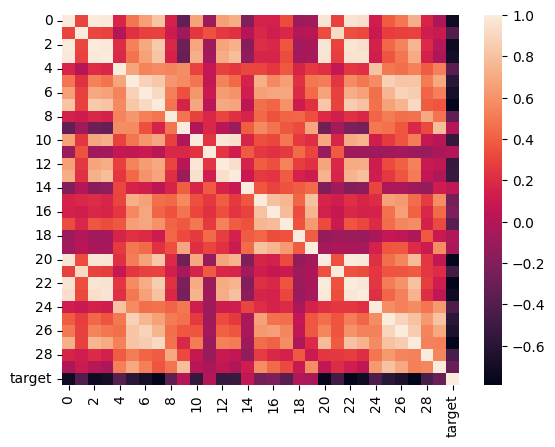

In [4]:
import seaborn as sns
import pandas as pd
df = pd.DataFrame(X_train)
df['target'] = y_train
corr = df.corr()
_ = sns.heatmap(corr)

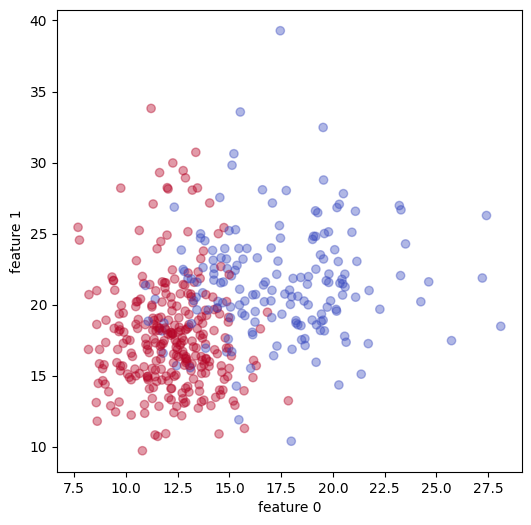

In [5]:
from matplotlib import pyplot as plt

def plot_2feats_against_target(X, y, feat1, feat2):
    plt.figure(figsize=(6, 6))
    plt.scatter(X[:, feat1], X[:, feat2], c=y, cmap='coolwarm', alpha=0.4)
    plt.xlabel(f'feature {feat1}')
    plt.ylabel(f'feature {feat2}')
    plt.show()

plot_2feats_against_target(X_train, y_train, 0, 1)

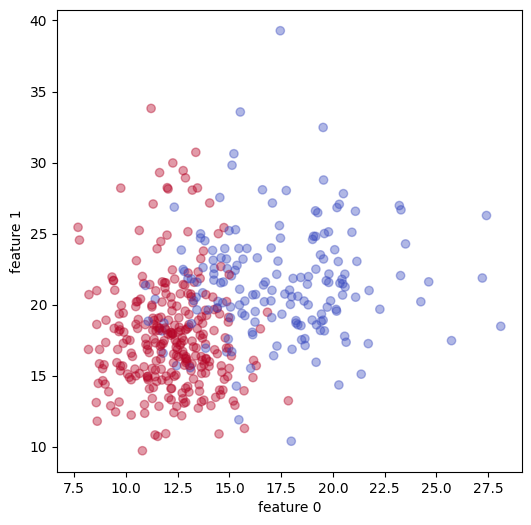

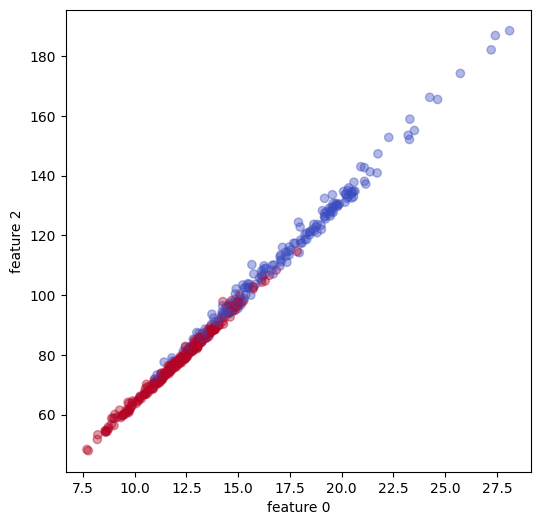

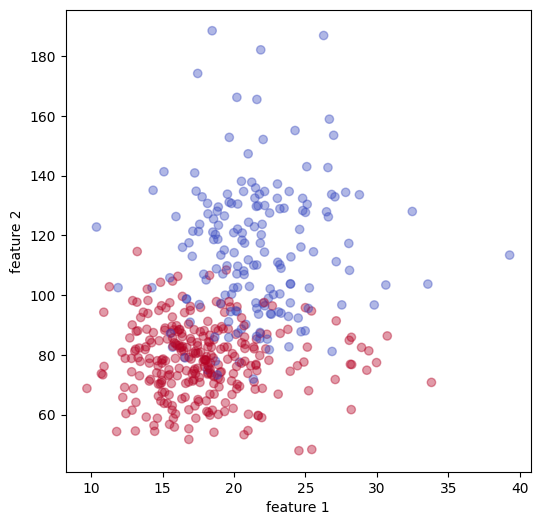

In [6]:
for i in range(3):
  for j in range(i+1, 3):
    plot_2feats_against_target(X_train, y_train, i, j)

In [7]:
X2D = X_train[:, [8, 22]]

In [8]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X2D, y_train)

LinearRegression()

In [9]:
y_pred = model.predict(X2D)
print(y_pred)

[ 0.97603725 -0.29431866  0.90227181  0.91105939  0.7296053   0.29206378
  0.71673403  0.94192063  0.79627941  0.06355564  0.75725701  0.06017468
  0.30637709  0.87861963  0.82143338  0.03783994 -0.38805724  0.29854172
  0.69813977  0.86744757  0.70149549  0.21241944  0.73408441  1.00743793
  0.50759044  0.46974396  0.94825179 -0.14649465  0.99228041  0.98815279
  0.46611504  0.72340588  0.2523135   0.09866465  0.58393871  0.85496234
  0.57760125  0.94906646  1.17193012  0.78450111  0.90035513 -0.66751637
  0.17374301  1.20933769  0.75498786  1.07185476  1.1555836   0.93862948
  1.00001554  0.9088792   0.58371742  0.86571869  0.9264617   0.61622985
  1.03545105  0.49341576  0.7189933   0.84098705  0.91243203  0.46710401
  0.79614192  0.77637695  0.48239774  0.53093491  0.84159686  0.72210513
  0.74087483  0.9293604   1.13313442  0.37987227  0.20400839  0.46950414
  0.54122823  0.68387206  0.38917255  0.86624437 -0.0749418   0.87068319
  0.83983774  1.02724245  0.8604072   0.47832178  0

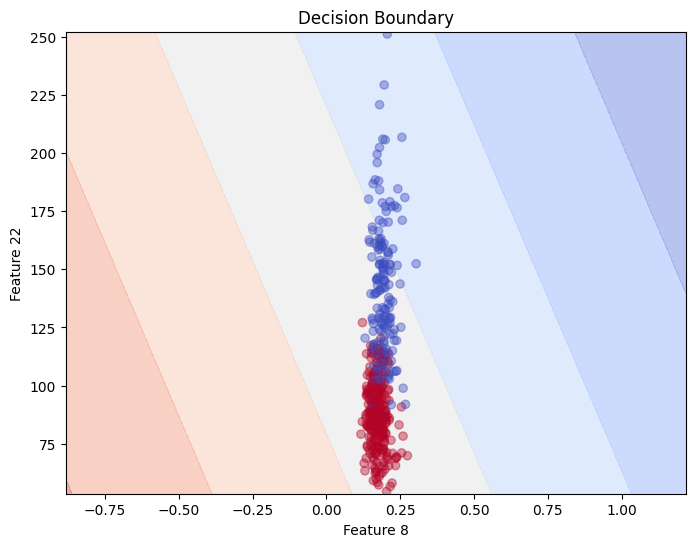

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(estimator, X, y, feat1, feat2, title='Decision Boundary'):
    # Select the two features for plotting
    X_plot = X[:, [feat1, feat2]]

    x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
    y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    # Predict on the meshgrid
    Z = estimator.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
    plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y, cmap='coolwarm', alpha=0.4)
    plt.xlabel(f'Feature {feat1}')
    plt.ylabel(f'Feature {feat2}')
    plt.title(title)
    plt.show()

plot_decision_boundary(model, X_train, y_train, 8, 22)

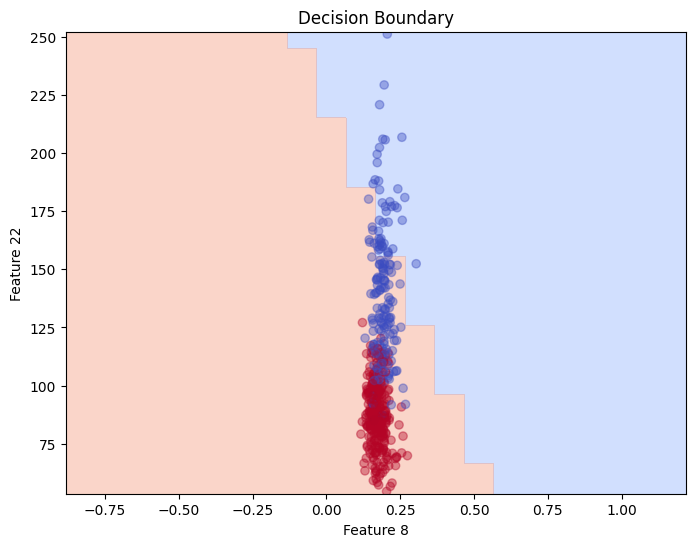

In [11]:
from sklearn.base import BaseEstimator, ClassifierMixin

class LinearClassifier(BaseEstimator, ClassifierMixin):
    def fit(self, X, y):
        self.model = LinearRegression()
        self.model.fit(X, y)
        return self

    def predict(self, X):
        return self.model.predict(X)>0

model = LinearClassifier()
model.fit(X2D, y_train)
plot_decision_boundary(model, X_train, y_train, 8, 22)

In [12]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X2D)
mse = mean_squared_error(y_train, y_pred)
print(mse)

0.3054945054945055


In [13]:
print((y_train==y_pred).mean())

0.6945054945054945


In [14]:
print(mse + (y_train==y_pred).mean())

1.0


In [15]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_train, y_pred))

0.6945054945054945


In [16]:
from sklearn.metrics import precision_score
print(precision_score(y_train, y_pred))

0.6729411764705883
